In [1]:
import pandas as pd
import numpy as np 
import nltk 
from gensim.models import word2vec
from sklearn.feature_extraction.text import TfidfVectorizer
import spacy 


In [2]:
review_data = pd.read_csv('../data/processed_data/drugsComTrain_text_preprocessing.csv')

In [3]:
review_data.head()

,Unnamed: 0,Unnamed: 0.1,drug_id,drugName,condition,review,rating,date,usefulCount,lowered_review,...,stemmed_review,lemmatized_review,review_len,stemmed_review_len,lem_review_len,word_count,sentiment_vader,sentiment_vader_label,sentiment_textblob,sentiment_textblob_label
0,0,0,206461,Valsartan,Left Ventricular Dysfunction,"""It has no side effect, I take it in combinati...",9.0,2012-05-20,27,"""it has no side effect, i take it in combinati...",...,no side effect take combin bystol mg fish oil,no side effect take combin bystol mg fish oil,46,45,45,9,-0.2960,Negative,0.000000,neutral
1,1,1,95260,Guanfacine,ADHD,"""My son is halfway through his fourth week of ...",8.0,2010-04-27,192,"""my son is halfway through his fourth week of ...",...,son halfway fourth week intuniv becam concern ...,son halfway fourth week intuniv becam concern ...,372,369,367,65,0.6929,Positive,0.114583,positive
2,2,2,92703,Lybrel,Birth Control,"""I used to take another oral contraceptive, wh...",5.0,2009-12-14,17,"""i used to take another oral contraceptive, wh...",...,use take anoth oral contracept pill cycl happi...,use take anoth oral contracept pill cycl happi...,403,401,401,70,0.2732,Positive,0.105000,positive
3,3,3,138000,Ortho Evra,Birth Control,"""This is my first time using any form of birth...",8.0,2015-11-03,10,"""this is my first time using any form of birth...",...,first time use form birth control glad went pa...,first time use form birth control glad went pa...,226,223,225,39,0.1027,Positive,0.300000,positive
4,4,4,35696,Buprenorphine / naloxone,Opiate Dependence,"""Suboxone has completely turned my life around...",9.0,2016-11-27,37,"""suboxone has completely turned my life around...",...,suboxon complet turn life around feel healthie...,suboxon complet turn life around feel healthie...,380,378,379,58,0.8934,Positive,0.147037,positive


In [4]:
column_names=['sentiment_vader_label','sentiment_textblob_label','stopwords_remove_review','drug_id','drugName','condition','rating']
review_data_new = review_data[column_names]



In [5]:
review_data_new.head()

,sentiment_vader_label,sentiment_textblob_label,stopwords_remove_review,drug_id,drugName,condition,rating
0,Negative,neutral,no side effect take combin bystol mg fish oil,206461,Valsartan,Left Ventricular Dysfunction,9.0
1,Positive,positive,son halfway fourth week intuniv becam concern ...,95260,Guanfacine,ADHD,8.0
2,Positive,positive,use take anoth oral contracept pill cycl happi...,92703,Lybrel,Birth Control,5.0
3,Positive,positive,first time use form birth control glad went pa...,138000,Ortho Evra,Birth Control,8.0
4,Positive,positive,suboxon complet turn life around feel healthie...,35696,Buprenorphine / naloxone,Opiate Dependence,9.0


In [6]:
tf_idf = TfidfVectorizer()

In [7]:
tfidf_matrix = tf_idf.fit_transform(review_data_new['stopwords_remove_review'])

In [8]:
tfidf_matrix.get_shape()

(160392, 55625)

In [9]:
feature_names = tf_idf.get_feature_names_out()

CLASSIFICATION USING MACHINE LEARNING AND DEEP LEARNING

In [10]:
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report

In [11]:
x=tfidf_matrix
y1=review_data_new['sentiment_textblob_label']


In [12]:
# spliting of train and test data for each of the sentiment analyzer : 
# tf_idf & y1(textblob label): 
X1_train, X1_test, y1_train, y1_test = train_test_split(x, y1, test_size=0.2, shuffle=True)



MACHINE LEARNING MODELS:
1.LOGISTIC REGRESSION 
2.SUPPORT VECTOR MACHINE

Logistic Regression:

In [13]:
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt 
import seaborn as sns

In [14]:
#Model the data using logreg
logreg = LogisticRegression()

In [15]:
# model training using the train dataset and label 
Text_blob_model = logreg.fit(X1_train,y1_train)


c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [16]:
# prediction for the validation data 
y1_pred=Text_blob_model.predict(X1_test)


In [17]:
conf_textblob= confusion_matrix(y1_test, y1_pred)
cm_display = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_textblob, display_labels = [False, True])

In [18]:
accuracy_textblob =  metrics.accuracy_score(y1_test,y1_pred)
print(accuracy_textblob)

0.9521182081735715


In [19]:
#confusion matrix metrics
print(classification_report(y1_test, y1_pred))

              precision    recall  f1-score   support

    negative       0.95      0.89      0.92      8536
     neutral       0.94      0.94      0.94      3292
    positive       0.95      0.98      0.97     20251

    accuracy                           0.95     32079
   macro avg       0.95      0.94      0.94     32079
weighted avg       0.95      0.95      0.95     32079



In [20]:
labels = ['positive','negative','neutral']

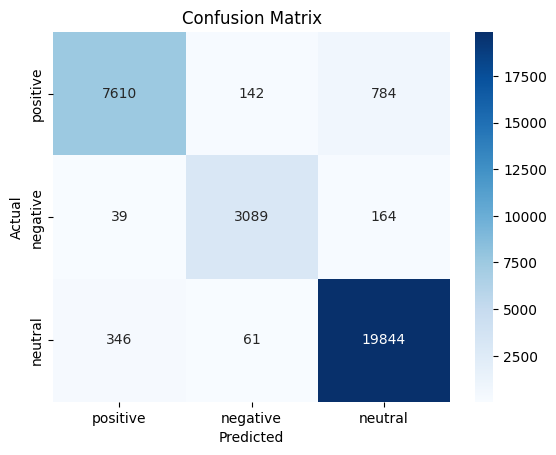

In [25]:
sns.heatmap(conf_textblob, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

LOGISTIC REGRESSION WITH COMPARISION TO VADER LABEL 

In [26]:
y2=review_data_new['sentiment_vader_label']
x=tfidf_matrix

In [27]:
# tf_idf & y2(vader label):
X2_train, X2_test, y2_train, y2_test = train_test_split(x, y2, test_size=0.2, shuffle=True)

In [28]:
vader_model = logreg.fit(X2_train,y2_train)

c:\Users\Ramya\AppData\Local\Programs\Python\Python39\lib\site-packages\sklearn\linear_model\_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [29]:
y2_pred=vader_model.predict(X2_test)

In [30]:
conf_vader = confusion_matrix(y2_test, y2_pred)
cm_display_vader = metrics.ConfusionMatrixDisplay(confusion_matrix = conf_vader, display_labels = [False, True])

In [31]:
accuracy_vader =  metrics.accuracy_score(y2_test,y2_pred)
print(accuracy_vader)

0.9236260481935222


In [32]:
#confusion matrix metrics
print(classification_report(y2_test, y2_pred))

              precision    recall  f1-score   support

    Negative       0.92      0.95      0.94     14822
     Neutral       0.95      0.48      0.64      1917
    Positive       0.92      0.95      0.94     15340

    accuracy                           0.92     32079
   macro avg       0.93      0.80      0.84     32079
weighted avg       0.92      0.92      0.92     32079



In [33]:
labels_vader = ['Positive','Negative','Neutral']

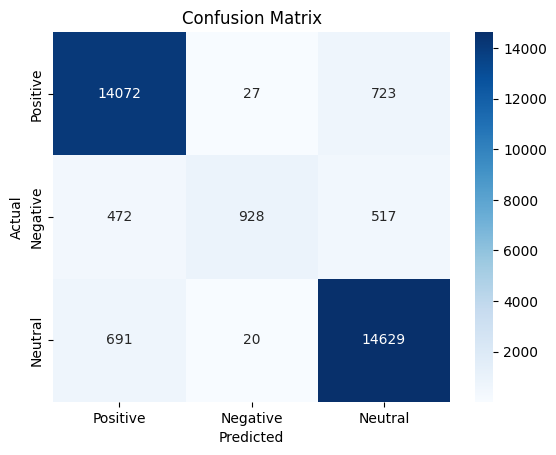

In [34]:
sns.heatmap(conf_vader, annot=True, fmt='d', cmap='Blues', xticklabels=labels_vader, yticklabels=labels_vader)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()